<a href="https://colab.research.google.com/github/hueglijoshua/CVI03.HS24-Computer-Vision/blob/main/04a_YOLO_object_detection_model_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python pycocotools matplotlib onnxruntime onnx
!pip install segment-anything
!pip install torch torchvision
!pip install sam2

# Initialization

In [45]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import os
import subprocess
import cv2
import torch
import requests
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tkinter import Tk, filedialog, simpledialog, messagebox
from pycocotools import mask as maskUtils

In [2]:
# helper functions
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    coords = np.array(coords)
    labels = np.array(labels)

    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25) 

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    """Displays all generated masks side by side."""
    
    num_masks = len(masks)
    fig, axes = plt.subplots(1, num_masks, figsize=(5 * num_masks, 5))  # Reduce size

    if num_masks == 1:  
        axes = [axes]  # Ensure axes is iterable if only one mask

    for i, (mask, score, ax) in zip(range(num_masks), zip(masks, scores, axes)):
        mask_overlay = (mask * 255).astype(np.uint8)  # Convert mask to grayscale
        image_with_mask = cv2.addWeighted(image, 0.7, cv2.cvtColor(mask_overlay, cv2.COLOR_GRAY2BGR), 0.3, 0)

        ax.imshow(image_with_mask)
        if point_coords is not None and input_labels is not None:
            show_points(point_coords, input_labels, ax)
        if box_coords is not None:
            show_box(box_coords, ax)

        ax.set_title(f"Mask {i+1}, Score: {score:.3f}", fontsize=12)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

# First time using SAM2

git clone https://github.com/facebookresearch/sam2.git && cd sam2

pip install -e .

In [ ]:
%cd ./sam2

In [ ]:
# Step 1: Define the download URL and target file path
url = "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt"
checkpoints_dir = "./checkpoints"
file_name = "sam2.1_hiera_large.pt"
file_path = os.path.join(checkpoints_dir, file_name)

# Step 2: Create the checkpoints directory if it doesn't exist
if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir)

# Step 3: Download the file
response = requests.get(url)

# Step 4: Save the content to the file
if response.status_code == 200:
    with open(file_path, "wb") as f:
        f.write(response.content)
    print(f"File downloaded and saved to {file_path}")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

# Selecting objects with SAM2

In [3]:
%cd ./sam2

C:\Users\joshu\Documents\computervision\CVI03.HS24-Computer-Vision\sam2


C:\Users\joshu\Documents\computervision\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "./checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
device = "cpu"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device = device)

predictor = SAM2ImagePredictor(sam2_model)

In [134]:
# functions
def select_folder():
    root = Tk()
    root.withdraw()  # Hide the root window
    folder_selected = filedialog.askdirectory(title="Select Image Folder")
    return folder_selected

def set_first_points(image, input_points, input_labels, image_path, image_id, image_folder):
    # Convert image from PIL to OpenCV format
    global image_cv

    input_points.clear()  # Reset points for new image
    input_labels.clear()
    
    image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    # Create a window and set mouse callback function
    cv2.namedWindow("Select Points")
    cv2.setMouseCallback("Select Points", select_point, (input_points, input_labels))

    # Display image in pop-up window
    while True:
        cv2.imshow("Select Points", image_cv)
        if cv2.waitKey(1) & 0xFF == 27:                                # Press 'Esc' to exit
            break

    cv2.destroyAllWindows()

    # Convert input_points to numpy array to prevent indexing issues
    #input_points = np.array(input_points) if input_points else np.empty((0, 2))
    #input_labels = np.array(input_labels) if input_labels else np.empty((0,))

    plot_image_with_points(image, input_points, input_labels)
    predict_masks(image, input_points, input_labels)
    
    ask_user_to_edit(image, input_points, input_labels, image_path, image_id, image_folder)


def select_point(event, x, y, flags, param):
    """Handles mouse click event to capture (x, y) coordinates and request a label."""
    input_points, input_labels = param

    if event == cv2.EVENT_LBUTTONDOWN:
        # Store selected point
        input_points.append([x, y])

        # Ask user for label (Foreground: 1, Background: 0)
        root = Tk()
        root.withdraw()  # Hide the main Tkinter window
        label = simpledialog.askinteger("Input", "Enter label (1 = Foreground, 0 = Background):", minvalue=0, maxvalue=1)
        
        if label is not None:
            input_labels.append(label)
            # Draw the point and label on the image
            cv2.putText(image_cv, f'({x},{y}): {label}', (x + 10, y + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            cv2.circle(image_cv, (x, y), 5, (0, 255, 0), -1)  # Draw point on image
    return input_points, input_labels
    
def plot_image_with_points(image, input_points, input_labels):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)  # Use the original image (PIL format)
    show_points(input_points, input_labels, plt.gca())
    plt.axis('on')
    plt.show()

    return image, input_points, input_labels

def predict_masks(image, input_points, input_labels):
    
    masks, scores, logits = predictor.predict(
        point_coords = input_points,
        point_labels = input_labels,
        multimask_output = True,
    )
    
    show_masks(image, masks, scores, point_coords=input_points, input_labels=input_labels, borders=True)
    
    return masks, scores

def edit_existing_points(image, input_points, input_labels):
    """Opens the image with existing points and allows adding new points."""
    global image_cv
    
    # Convert image from PIL to OpenCV format
    image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    
    # Create a copy to ensure updates appear in real-time
    temp_image = image_cv.copy()
    
    # Draw existing points
    for (x, y), label in zip(input_points, input_labels):
        cv2.putText(temp_image, f'({x},{y}): {label}', (x + 10, y + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        cv2.circle(temp_image, (x, y), 5, (0, 255, 0), -1)  # Draw point on image
    
    # Create a window and set mouse callback function
    cv2.namedWindow("Edit Points")
    cv2.setMouseCallback("Edit Points", select_point, param=(input_points, input_labels))
    
    # Display image in pop-up window
    while True:
        display_image = temp_image.copy()
        for (x, y), label in zip(input_points, input_labels):
            cv2.putText(display_image, f'({x},{y}): {label}', (x + 10, y + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            cv2.circle(display_image, (x, y), 5, (0, 255, 0), -1)  # Draw point on image
        
        cv2.imshow("Edit Points", display_image)
        if cv2.waitKey(1) & 0xFF == 27:  # Press 'Esc' to exit
            break
    
    cv2.destroyAllWindows()

    return input_points, input_labels

def ask_user_to_edit(image, input_points, input_labels, image_path, image_id, image_folder):
    """Asks the user if they want to edit points. If yes, call edit_existing_points."""
    root = Tk()
    root.withdraw()  # Hide the main Tkinter window
    response = messagebox.askyesno("Edit Points", "Do you want to edit the points?")
    
    if response:
        edit_existing_points(image, input_points, input_labels)
        print(f"{input_points}")
        plot_image_with_points(image, input_points, input_labels)
        predict_masks(image, input_points, input_labels)
        return ask_user_to_edit(image, input_points, input_labels, image_path, image_id, image_folder)  # Recursively call, pass the updated state
    else:
        masks, scores = predict_masks(image, input_points, input_labels)
        selected_mask_index = choose_mask(image, masks, scores)
        mask_input = masks[selected_mask_index]
        print(f"User selected Mask {selected_mask_index + 1}")
        # Print out all selected points and labels
        print("All selected points and labels:")
        for point, label in zip(input_points, input_labels):
            print(f"Point: {point}, Label: {label}")

        # Convert the selected mask to COCO format and save it
        image_id = image_id                                                      # Set the image ID (can be set dynamically based on your setup)
        category_id = 0                                                          # 0: fractured
        coco_annotation = mask_to_coco(mask_input, image_id, category_id)

        # Get the directory of the image
        image_dir = os.path.dirname(image_path)
        
        # Create a new folder for annotations if it doesn't exist
        annotation_dir = os.path.join(image_dir, 'annotations')
        if not os.path.exists(annotation_dir):
            os.makedirs(annotation_dir)

        # Define the path for the COCO annotation JSON file
        image_name = os.path.splitext(os.path.basename(image_path))[0]
        json_filename = os.path.join(annotation_dir, f"{image_id}.json")

        # Load existing annotations (if any)
        annotations = {"annotations": []}
        if os.path.exists(json_filename):
            try:
                with open(json_filename, 'r') as f:
                    annotations = json.load(f)
            except json.JSONDecodeError:
                print(f"Error: Could not decode JSON in {json_filename}. Starting fresh.")
                annotations = {"annotations": []}
            except Exception as e:
                print(f"Unexpected error: {e}. Starting fresh.")
                annotations = {"annotations": []}

        # Append the new annotation to the list
        annotations["annotations"].append(coco_annotation)

        # Save the updated annotations back to the JSON file
        with open(json_filename, 'w') as f:
            json.dump(annotations, f, indent=4)

        print(f"Annotation saved to {json_filename}")

        # Move the image to the new "images" folder and rename it to image_id.jpg
        images_dir = os.path.join(image_dir, 'images')
        if not os.path.exists(images_dir):
            os.makedirs(images_dir)
        
        new_image_path = os.path.join(images_dir, f"{image_id}.jpg")
        shutil.move(image_path, new_image_path)  # Move and rename the image

        print(f"Image moved and renamed to {new_image_path}")

        
        # Get all the images from the folder
        image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if not image_files:
            print("No more images to process. Exiting function.")
            return
        
        image_files.sort()  # Ensure images are processed in order

        image_path = os.path.join(image_folder, image_files[0])
        image_id += 1

        # Open the next image
        image = Image.open(image_path)
        image = np.array(image.convert("RGB"))

        input_points = []
        input_labels = []

        predict_images(image, input_points, input_labels, image_path, image_id, image_folder)

# Function to display masks side-by-side without individual labels
def choose_mask(image, masks, scores):
    """Displays the three masks side by side and allows the user to select one."""
    # Ask the user for a choice (1, 2, or 3)
    root = Tk()
    root.withdraw()
    choice = simpledialog.askinteger("Choose Mask", "Select a mask (1, 2, or 3):", minvalue=1, maxvalue=3)
    
    selected_index = (choice - 1) if choice else 0  # Default to first mask

    # Convert mask to a light blue overlay
    mask = masks[selected_index].astype(np.uint8) * 255  # Convert mask to 0-255 range
    light_blue = np.zeros_like(image, dtype=np.uint8)
    light_blue[:, :, 0] = 255  # Blue channel
    light_blue[:, :, 1] = 200  # Green channel
    light_blue[:, :, 2] = 100  # Red channel

    mask_overlay = cv2.bitwise_and(light_blue, light_blue, mask=mask)
    image_with_mask = cv2.addWeighted(image, 0.7, mask_overlay, 0.3, 0)

    # Display only the selected mask
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(image_with_mask, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for Matplotlib
    plt.title(f"Selected Mask {selected_index + 1}, Score: {scores[selected_index]:.3f}", fontsize=12)
    plt.axis("on")
    plt.show()

    return selected_index

def mask_to_coco(mask, image_id, category_id):
    """
    Converts a binary mask to COCO polygon format.
    
    Args:
        mask (np.array): Binary mask (0 and 1).
        image_id (int): Image ID.
        category_id (int): Class ID.
        
    Returns:
        dict: COCO annotation.
    """
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    segmentation = []
    for contour in contours:
        if contour.size >= 6:                                             # A valid polygon requires at least 3 points
            segmentation.append(contour.flatten().tolist())

    rle = maskUtils.encode(np.asfortranarray(mask.astype(np.uint8)))
    area = maskUtils.area(rle).item()
    bbox = maskUtils.toBbox(rle).tolist()                                 # [x, y, width, height]

    annotation = {
        "image_id": image_id,
        "category_id": category_id,
        "segmentation": segmentation,                                     # [x1, y1, x2, y2, ..., xn, yn]
        "area": area,
        "bbox": bbox,
        "iscrowd": 0                                              # crowded object: where boundaries are not well defined due to overlapping/occlusion
    }
    return annotation

def predict_images(image, input_points, input_labels, image_path, image_id, image_folder):
    predictor.set_image(image)
    input_points = []
    input_labels = []
    set_first_points(image, input_points, input_labels, image_path, image_id, image_folder)


Selected folder: C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation
Total 2 images found in selected folder
Opening first image: C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation\1.jpg


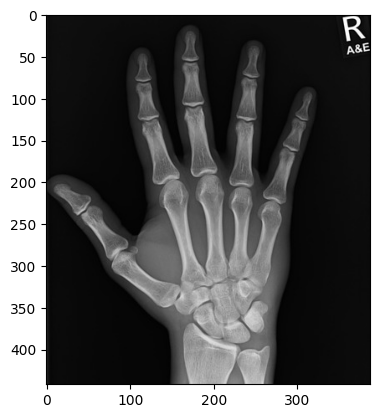

In [135]:
# User selects the folder
image_folder = select_folder()
print(f"Selected folder: {image_folder}")

# Get the first image in the folder
if image_folder:
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Total {len(image_files)} images found in selected folder")
    
    if image_files:
        first_image_path = os.path.join(image_folder, image_files[0])
        image_path = first_image_path
        image_id = 1
        print(f"Opening first image: {first_image_path}")
        
        # Load the image
        image = Image.open(first_image_path)
        image = np.array(image.convert("RGB"))
        
        # Display the image
        plt.imshow(image)
        plt.axis("on")
        plt.show()
    else:
        print("No images found in the selected folder.")
else:
    print("No folder selected.")
    

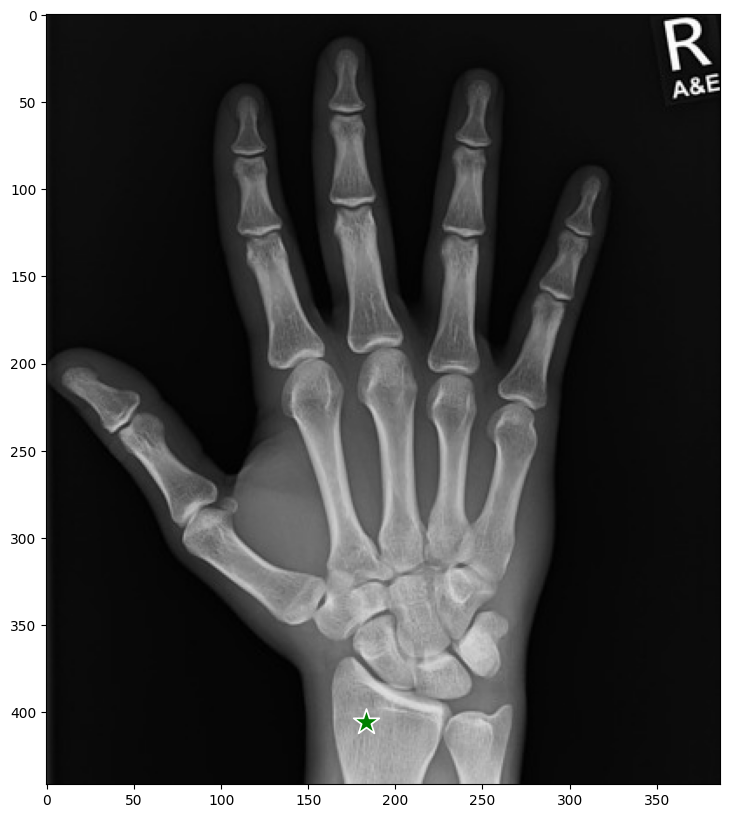

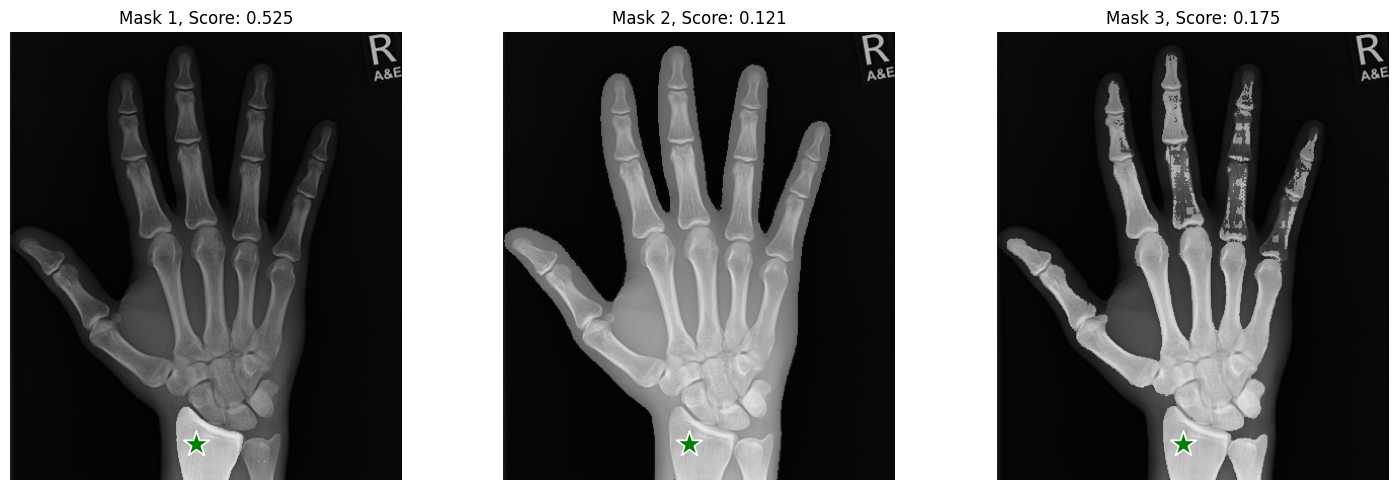

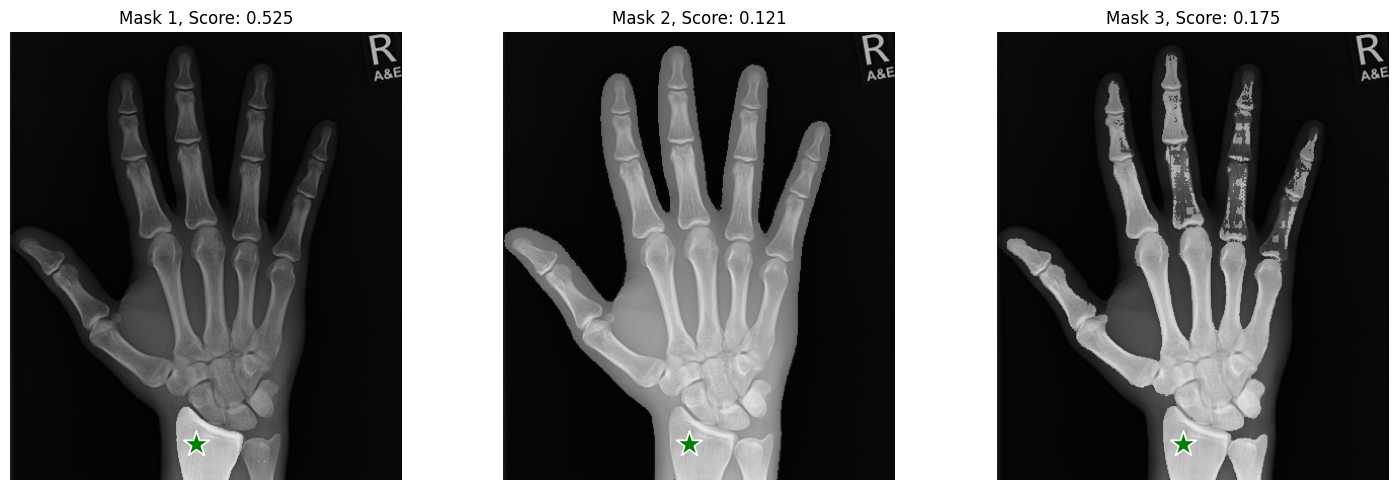

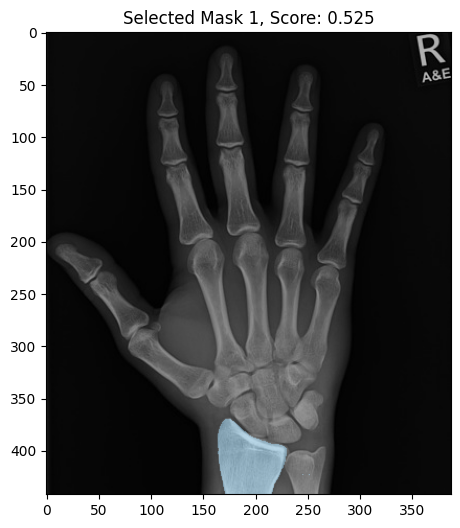

User selected Mask 1
All selected points and labels:
Point: [183, 406], Label: 1
Annotation saved to C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation\annotations\1.json
Image moved and renamed to C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation\images\1.jpg


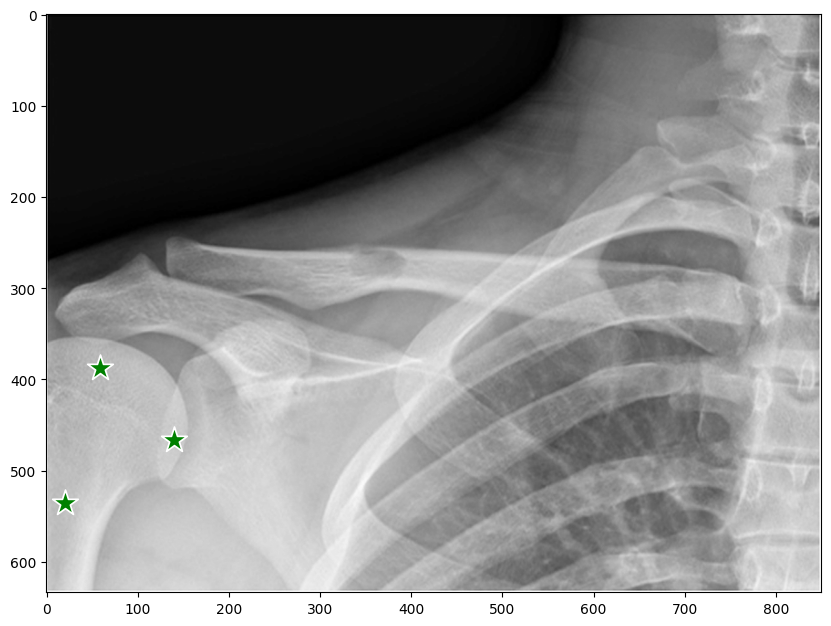

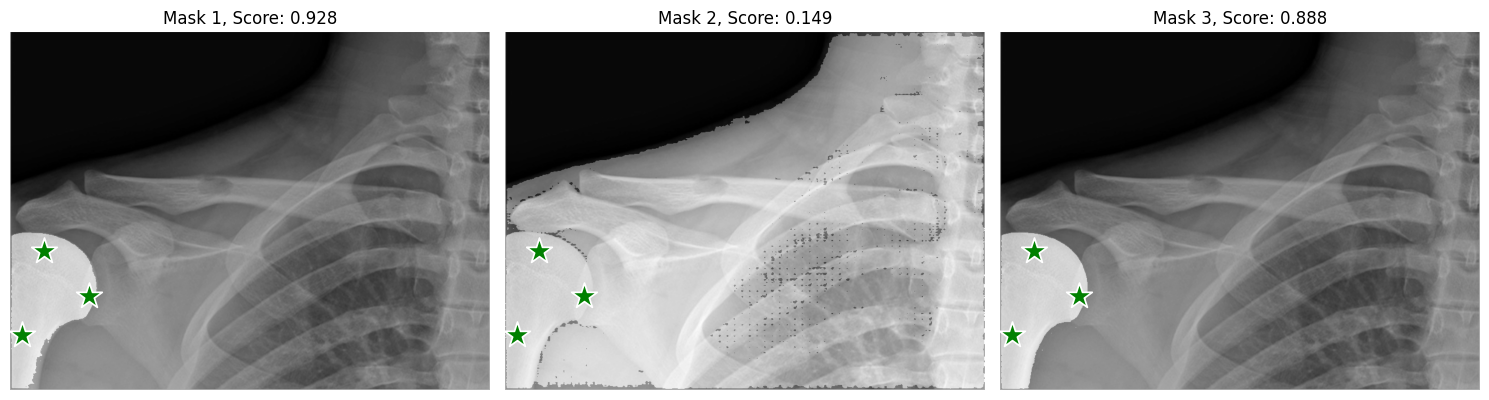

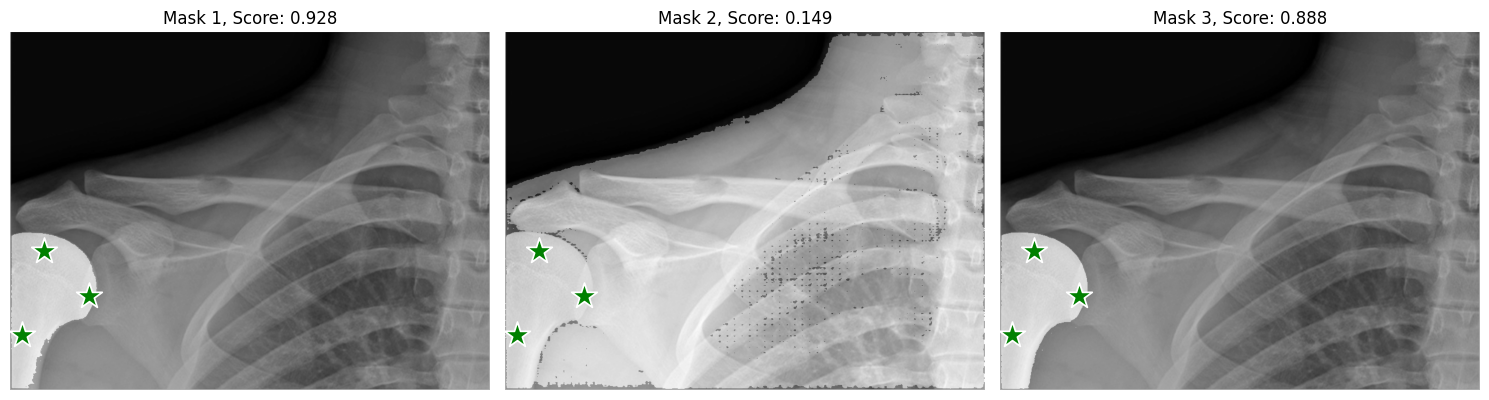

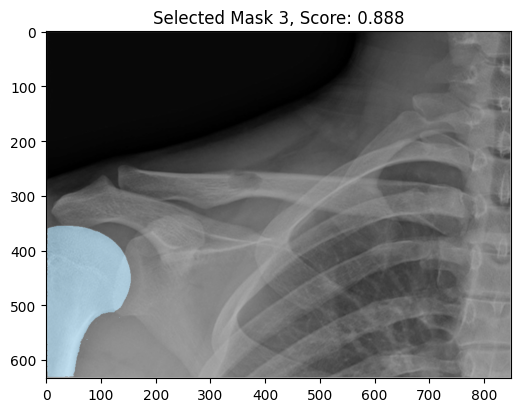

User selected Mask 3
All selected points and labels:
Point: [59, 387], Label: 1
Point: [140, 467], Label: 1
Point: [20, 536], Label: 1
Annotation saved to C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation\annotations\2.json
Image moved and renamed to C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation\images\2.jpg
No more images to process. Exiting function.


In [136]:
input_points = []
input_labels = []
image_cv = None
predict_images(image, input_points, input_labels, image_path, image_id, image_folder)
